<a href="https://colab.research.google.com/github/ZeninKris/zmm-movilidad-predictiva/blob/main/notebooks/03_Feature_Engineering_Clima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Feature Engineering: Clima

## Objetivo
Incorporar datos climáticos históricos al esqueleto temporal,
discretizando la precipitación en niveles de impacto vial
basados en el comportamiento específico de la lluvia en Monterrey.

## Fuente de datos
Open-Meteo Archive API — datos horarios históricos verificados.
Punto de referencia: Aeropuerto Internacional MTY (MMMY)
lat=25.7785, lon=-100.1070
Justificación: punto oficial SMN más cercano a los parques
industriales de Apodaca (9km) y Pesquería (6km) —
los municipios con mayor concentración industrial del proyecto.

Período con datos reales: 2023-01-01 a 2026-03-17
Las horas posteriores a esa fecha tienen precipitacion_mm = 0
por ausencia de datos históricos disponibles — limitación documentada.

## Escala de lluvia — basada en comportamiento vial regio
- Nivel 0: 0mm         → seco, condiciones normales
- Nivel 1: 0.1 a 5mm  → brisnita, pavimento resbaladizo,
                         aumenta choques por alcance
- Nivel 2: 5 a 20mm   → lluvia moderada, encharcamientos menores
- Nivel 3: 20 a 50mm  → lluvia fuerte, pasos a desnivel críticos
- Nivel 4: >50mm      → torrencial, alertas de Protección Civil

## Estacionalidad del clima en Monterrey
Temporada seca:     diciembre, enero, febrero, marzo
Transición:         abril, mayo
Temporada lluviosa: junio, julio, agosto, septiembre, octubre
Los meses de mayor riesgo vial son septiembre y octubre
por la combinación de lluvia fuerte + tráfico industrial intenso

In [1]:
# ============================================================
# CELDA 1 — Descarga de datos climáticos históricos
# Fuente: Open-Meteo Archive API
# ============================================================

import pandas as pd
import requests
from google.colab import drive
drive.mount('/content/drive')

PROCESSED = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/'

# --- 1.1 Cargar el esqueleto del Pilar 2 ---
ruta_esqueleto = PROCESSED + 'esqueleto_tiempo_eventos.csv'
df_super = pd.read_csv(ruta_esqueleto)
df_super['fecha_hora'] = pd.to_datetime(df_super['fecha_hora'])

print(f"Esqueleto cargado: {df_super.shape[0]:,} filas")

# --- 1.2 Descargar clima desde Open-Meteo ---
# Punto de referencia: Aeropuerto Internacional MTY (MMMY)
# Justificación: punto oficial SMN más cercano a los parques
# industriales de Apodaca (9km) y Pesquería (6km)
lat, lon = 25.7785, -100.1070

# Datos históricos disponibles hasta la fecha actual
# Las horas futuras del esqueleto (post API) tendrán NaN
url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date=2023-01-01&end_date=2026-03-17"
    f"&hourly=temperature_2m,precipitation"
    f"&timezone=America%2FMonterrey"
)

print("Descargando datos climáticos del Aeropuerto MTY...")
response = requests.get(url)
data = response.json()

# --- 1.3 Construir DataFrame de clima ---
df_clima = pd.DataFrame({
    'fecha_hora':       pd.to_datetime(data['hourly']['time']),
    'temperatura_c':    data['hourly']['temperature_2m'],
    'precipitacion_mm': data['hourly']['precipitation']
})

print(f"Datos climáticos descargados: {len(df_clima):,} horas")
print(f"Período: {df_clima['fecha_hora'].min()} → {df_clima['fecha_hora'].max()}")

# --- 1.4 Merge con el esqueleto ---
df_super = df_super.merge(df_clima, on='fecha_hora', how='left')

# --- 1.5 Documentar horas sin datos climáticos ---
sin_clima = df_super['temperatura_c'].isna().sum()
print(f"\nHoras sin datos climáticos (post 2026-03-17): {sin_clima:,}")
print(f"  → Se imputarán con 0 en precipitacion_mm en la Celda 2")

# --- 1.6 Guardar ---
ruta_salida = PROCESSED + 'esqueleto_tiempo_eventos_clima.csv'
df_super.to_csv(ruta_salida, index=False)
print(f"\nArchivo guardado: {ruta_salida}")

# --- 1.7 Verificación rápida ---
print(f"\nEjemplos de horas con precipitación:")
print(df_super[df_super['precipitacion_mm'] > 0][
    ['fecha_hora', 'temperatura_c', 'precipitacion_mm']
].head(8))

Mounted at /content/drive
Esqueleto cargado: 35,064 filas
Descargando datos climáticos del Aeropuerto MTY...
Datos climáticos descargados: 28,128 horas
Período: 2023-01-01 00:00:00 → 2026-03-17 23:00:00

Horas sin datos climáticos (post 2026-03-17): 6,936
  → Se imputarán con 0 en precipitacion_mm en la Celda 2

Archivo guardado: /content/drive/MyDrive/Proyecto_ZMM/data_processed/esqueleto_tiempo_eventos_clima.csv

Ejemplos de horas con precipitación:
             fecha_hora  temperatura_c  precipitacion_mm
199 2023-01-09 07:00:00           14.6               0.2
200 2023-01-09 08:00:00           14.9               0.5
483 2023-01-21 03:00:00           16.0               0.1
484 2023-01-21 04:00:00           16.0               0.2
485 2023-01-21 05:00:00           16.0               0.1
486 2023-01-21 06:00:00           15.7               0.1
507 2023-01-22 03:00:00           16.9               0.1
720 2023-01-31 00:00:00           16.4               0.2


In [2]:
# ============================================================
# CELDA 2 — Discretización de precipitación en nivel_lluvia
# ============================================================

import pandas as pd
import numpy as np

ruta_super = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/esqueleto_tiempo_eventos_clima.csv'
df_super = pd.read_csv(ruta_super)
df_super['fecha_hora'] = pd.to_datetime(df_super['fecha_hora'])

# --- 2.1 Idempotencia ---
if 'precipitacion_mm' not in df_super.columns:
    print("precipitacion_mm ya no existe — archivo ya procesado. No re-ejecutar.")
else:
    print("Iniciando discretización de precipitación...")

    # --- 2.2 Imputar NaN en horas futuras (post 2026-03-17) ---
    # Razón: horas sin datos reales → asumimos condición seca
    # Es conservador pero honesto — no inventamos lluvia donde no hay registro
    nan_antes = df_super['precipitacion_mm'].isna().sum()
    df_super['precipitacion_mm'] = df_super['precipitacion_mm'].fillna(0)
    df_super['temperatura_c']    = df_super['temperatura_c'].fillna(
        df_super['temperatura_c'].median()
    )
    print(f"  NaN imputados en precipitacion_mm: {nan_antes:,}")

    # --- 2.3 Discretizar en nivel_lluvia ---
    # Escala basada en comportamiento vial regio (ver Markdown inicial)
    cortes   = [-1.0, 0.09, 5.0, 20.0, 50.0, 999.0]
    etiquetas = [0, 1, 2, 3, 4]

    df_super['nivel_lluvia'] = pd.cut(
        df_super['precipitacion_mm'],
        bins=cortes,
        labels=etiquetas
    ).fillna(0).astype(int)

    # --- 2.4 Verificar nivel 4 ---
    nivel4 = (df_super['nivel_lluvia'] == 4).sum()
    print(f"\n  Registros nivel 4 (>50mm/hora): {nivel4}")
    if nivel4 == 0:
        print("  → Cero eventos torrenciales en el período 2023-2026.")
        print("    Esto es consistente con Monterrey — eventos >50mm/h")
        print("    son extremadamente raros (histórico: Huracán Alex 2010).")
        print("    El nivel 4 permanece en la escala para datos futuros.")

    # --- 2.5 Eliminar columna cruda ---
    df_super.drop(columns=['precipitacion_mm'], inplace=True)

    # --- 2.6 Guardar ---
    df_super.to_csv(ruta_super, index=False)
    print(f"\n  Archivo guardado con nivel_lluvia")

# --- 2.7 Distribución final ---
print("\nDistribución de nivel_lluvia:")
print("-" * 40)
nombres = {0:'Seco', 1:'Brisnita', 2:'Moderada', 3:'Fuerte', 4:'Torrencial'}
dist = df_super['nivel_lluvia'].value_counts().sort_index()
for nivel, count in dist.items():
    pct = count / len(df_super) * 100
    barra = '█' * int(pct / 1)
    nombre = nombres.get(nivel, '?')
    print(f"  Nivel {nivel} ({nombre:<10}): {count:>6,} ({pct:>5.1f}%) {barra}")

# --- 2.8 Verificación por mes ---
print("\nPromedio de nivel_lluvia por mes:")
df_super['mes'] = pd.to_datetime(df_super['fecha_hora']).dt.month
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']
lluvia_mes = df_super.groupby('mes')['nivel_lluvia'].mean()
for mes, val in lluvia_mes.items():
    barra = '█' * int(val * 20)
    print(f"  {meses[mes-1]}: {val:.3f} {barra}")

Iniciando discretización de precipitación...
  NaN imputados en precipitacion_mm: 6,936

  Registros nivel 4 (>50mm/hora): 0
  → Cero eventos torrenciales en el período 2023-2026.
    Esto es consistente con Monterrey — eventos >50mm/h
    son extremadamente raros (histórico: Huracán Alex 2010).
    El nivel 4 permanece en la escala para datos futuros.

  Archivo guardado con nivel_lluvia

Distribución de nivel_lluvia:
----------------------------------------
  Nivel 0 (Seco      ): 32,550 ( 92.8%) ████████████████████████████████████████████████████████████████████████████████████████████
  Nivel 1 (Brisnita  ):  2,455 (  7.0%) ███████
  Nivel 2 (Moderada  ):     58 (  0.2%) 
  Nivel 3 (Fuerte    ):      1 (  0.0%) 

Promedio de nivel_lluvia por mes:
  Ene: 0.043 
  Feb: 0.040 
  Mar: 0.060 █
  Abr: 0.061 █
  May: 0.097 █
  Jun: 0.096 █
  Jul: 0.087 █
  Ago: 0.039 
  Sep: 0.104 ██
  Oct: 0.112 ██
  Nov: 0.073 █
  Dic: 0.067 █


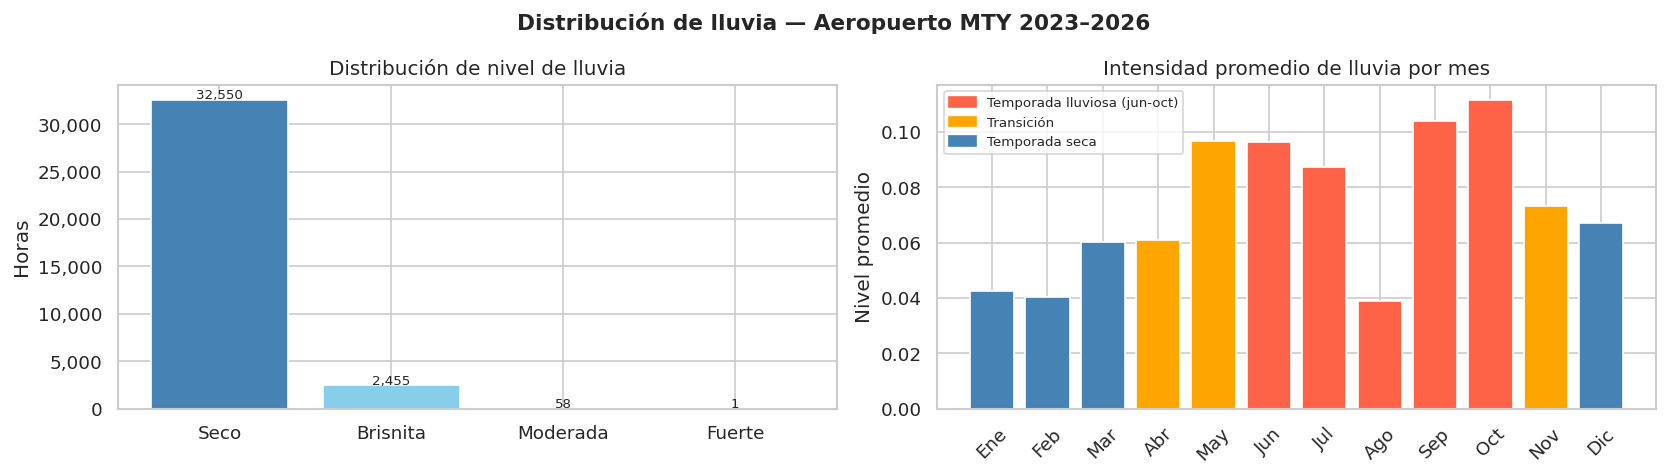

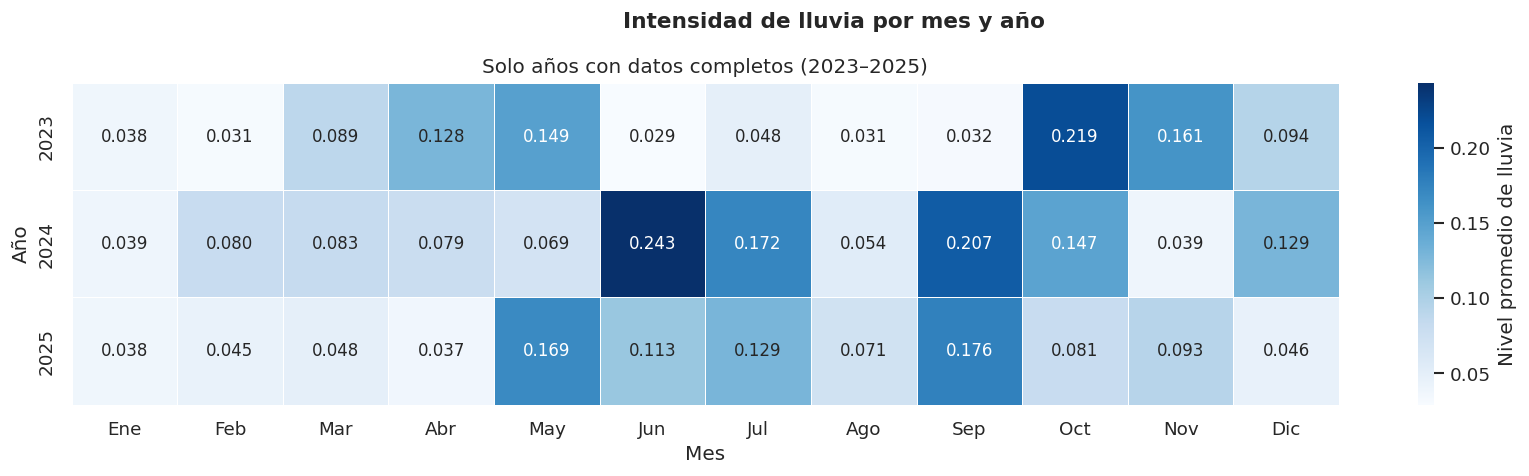

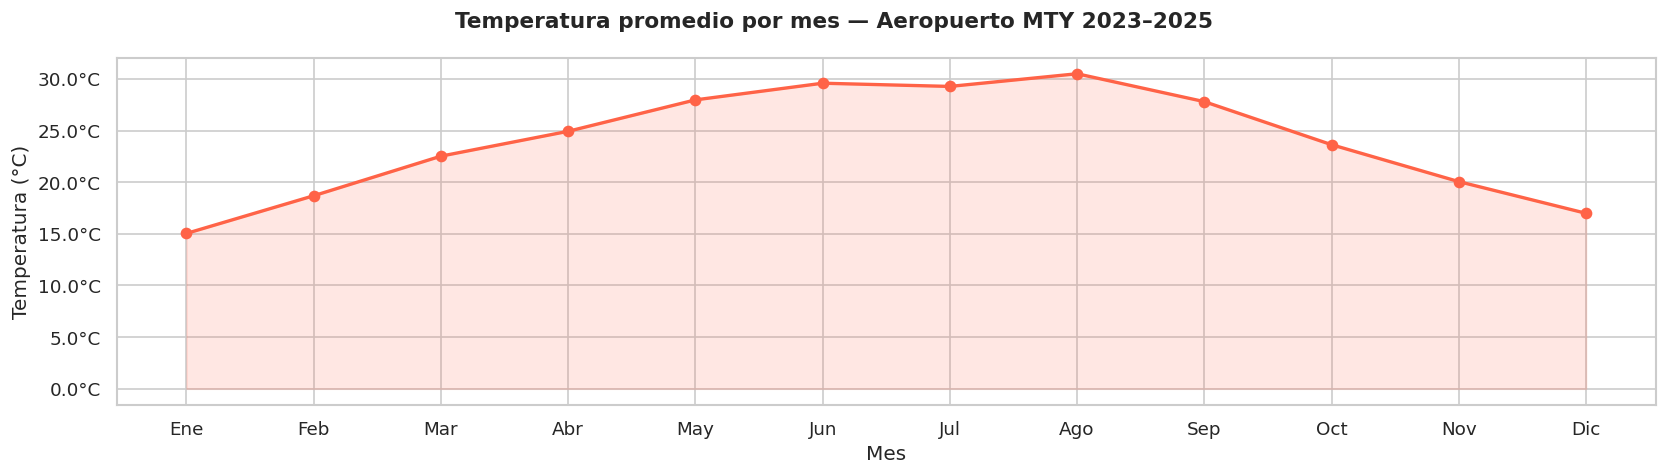

✅ 3 figuras generadas y guardadas


In [3]:
# ============================================================
# CELDA 3 — Visualizaciones del clima
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

df_super['fecha_hora'] = pd.to_datetime(df_super['fecha_hora'])
df_super['año'] = df_super['fecha_hora'].dt.year
df_super['mes'] = df_super['fecha_hora'].dt.month

meses_labels = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']

# ============================================================
# FIGURA 1 — Distribución de nivel_lluvia y por mes
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución de lluvia — Aeropuerto MTY 2023–2026',
             fontsize=13, fontweight='bold')

# 1A — Distribución general
nombres = {0:'Seco', 1:'Brisnita', 2:'Moderada', 3:'Fuerte', 4:'Torrencial'}
colores = {0:'steelblue', 1:'skyblue', 2:'orange', 3:'tomato', 4:'darkred'}
dist = df_super['nivel_lluvia'].value_counts().sort_index()
bars = axes[0].bar(
    [nombres[i] for i in dist.index],
    dist.values,
    color=[colores[i] for i in dist.index],
    edgecolor='white'
)
axes[0].set_title('Distribución de nivel de lluvia')
axes[0].set_ylabel('Horas')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=8)

# 1B — Promedio de nivel_lluvia por mes
lluvia_mes = df_super.groupby('mes')['nivel_lluvia'].mean()
colores_mes = ['tomato' if m in [6,7,8,9,10] else
               'orange' if m in [4,5,11] else
               'steelblue' for m in lluvia_mes.index]
axes[1].bar([meses_labels[m-1] for m in lluvia_mes.index],
            lluvia_mes.values,
            color=colores_mes, edgecolor='white')
axes[1].set_title('Intensidad promedio de lluvia por mes')
axes[1].set_ylabel('Nivel promedio')
axes[1].tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
leyenda = [
    Patch(color='tomato',    label='Temporada lluviosa (jun-oct)'),
    Patch(color='orange',    label='Transición'),
    Patch(color='steelblue', label='Temporada seca')
]
axes[1].legend(handles=leyenda, fontsize=8)

plt.tight_layout()
plt.savefig('nb03_fig1_distribucion_lluvia.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 — Heatmap lluvia por mes y año
# ============================================================
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Intensidad de lluvia por mes y año',
             fontsize=13, fontweight='bold')

pivot = df_super[df_super['año'] <= 2025].groupby(
    ['año', 'mes'])['nivel_lluvia'].mean().unstack()
pivot.columns = [meses_labels[m-1] for m in pivot.columns]

sns.heatmap(pivot, ax=ax, cmap='Blues', linewidths=0.3,
            annot=True, fmt='.3f',
            cbar_kws={'label': 'Nivel promedio de lluvia'})
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
ax.set_title('Solo años con datos completos (2023–2025)')

plt.tight_layout()
plt.savefig('nb03_fig2_heatmap_lluvia.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 — Temperatura promedio por mes
# ============================================================
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Temperatura promedio por mes — Aeropuerto MTY 2023–2025',
             fontsize=13, fontweight='bold')

temp_mes = df_super[df_super['año'] <= 2025].groupby('mes')['temperatura_c'].mean()
ax.plot([meses_labels[m-1] for m in temp_mes.index],
        temp_mes.values,
        color='tomato', linewidth=2, marker='o', markersize=6)
ax.fill_between(range(len(temp_mes)), temp_mes.values,
                alpha=0.15, color='tomato')
ax.set_ylabel('Temperatura (°C)')
ax.set_xlabel('Mes')
ax.set_xticks(range(len(temp_mes)))
ax.set_xticklabels([meses_labels[m-1] for m in temp_mes.index])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°C'))

plt.tight_layout()
plt.savefig('nb03_fig3_temperatura.png', bbox_inches='tight')
plt.show()

print("✅ 3 figuras generadas y guardadas")

## Conclusiones — Notebook 03

### Datos climáticos
- Fuente: Open-Meteo Archive API, punto Aeropuerto MTY (MMMY)
- Período con datos reales: 2023-01-01 a 2026-03-17
- Horas sin datos (futuro): 6,936 → imputadas con precipitacion=0
  y temperatura=mediana del período histórico

### Distribución de nivel_lluvia
- Nivel 0 (Seco):      92.8% — Monterrey es predominantemente seco
- Nivel 1 (Brisnita):   7.0% — evento más frecuente de lluvia
- Nivel 2 (Moderada):   0.2% — lluvia real, poco frecuente
- Nivel 3 (Fuerte):     0.0% — 1 solo evento en 3 años
- Nivel 4 (Torrencial): 0.0% — ninguno en el período (consistente
  con histórico regio — último evento: Huracán Alex 2010)

### Hallazgo clave — variabilidad interanual
Cada año tiene su propio patrón de lluvia:
- 2023: octubre más lluvioso (0.219)
- 2024: junio más lluvioso (0.243) — temporada temprana
- 2025: mayo más lluvioso (0.169) — adelantado
El modelo aprende estos patrones año por año, no del promedio.

### Variables climáticas incluidas
- `nivel_lluvia` (0-4): principal variable climática para el modelo
- `temperatura_c`: contexto térmico, relevante para comportamiento vial

### Trabajo futuro no implementado por alcance
- Detección de frentes fríos (caídas bruscas de temperatura)
- Neblina (requiere variable adicional de Open-Meteo)
- Múltiples puntos geográficos para microclimas de la ZMM
```